In [1]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from pylab import rcParams

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import os

print(os.path.exists(r"C:\Users\Hp\Downloads\creditcard.csv"))

True


In [4]:
import os

path = r"C:\Users\Hp\Downloads\creditcard.csv"

print("Exists:", os.path.exists(path))
print("Is file:", os.path.isfile(path))
print("Is folder:", os.path.isdir(path))

Exists: True
Is file: False
Is folder: True


In [5]:
data = pd.read_csv(
    r"C:\Users\Hp\Downloads\creditcard.csv\creditcard.csv"
)

In [7]:
import os

path = r"C:\Users\Hp\Downloads\creditcard.csv"

print("Exists:", os.path.exists(path))
print("Is file:", os.path.isfile(path))
print("Is folder:", os.path.isdir(path))

if os.path.exists(path):
    print("Size:", os.path.getsize(path), "bytes")

Exists: True
Is file: False
Is folder: True
Size: 0 bytes


In [8]:
import os

folder = r"C:\Users\Hp\Downloads\creditcard.csv"

print(os.listdir(folder))

['creditcard.csv']


In [9]:
data = pd.read_csv(
    r"C:\Users\Hp\Downloads\creditcard.csv\creditcard.csv"
)

print(data.shape)
print(data.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
data.isnull().values.any()

np.False_

In [12]:
count_classes = data['Class'].value_counts(sort=True)

print(count_classes)

Class
0    284315
1       492
Name: count, dtype: int64


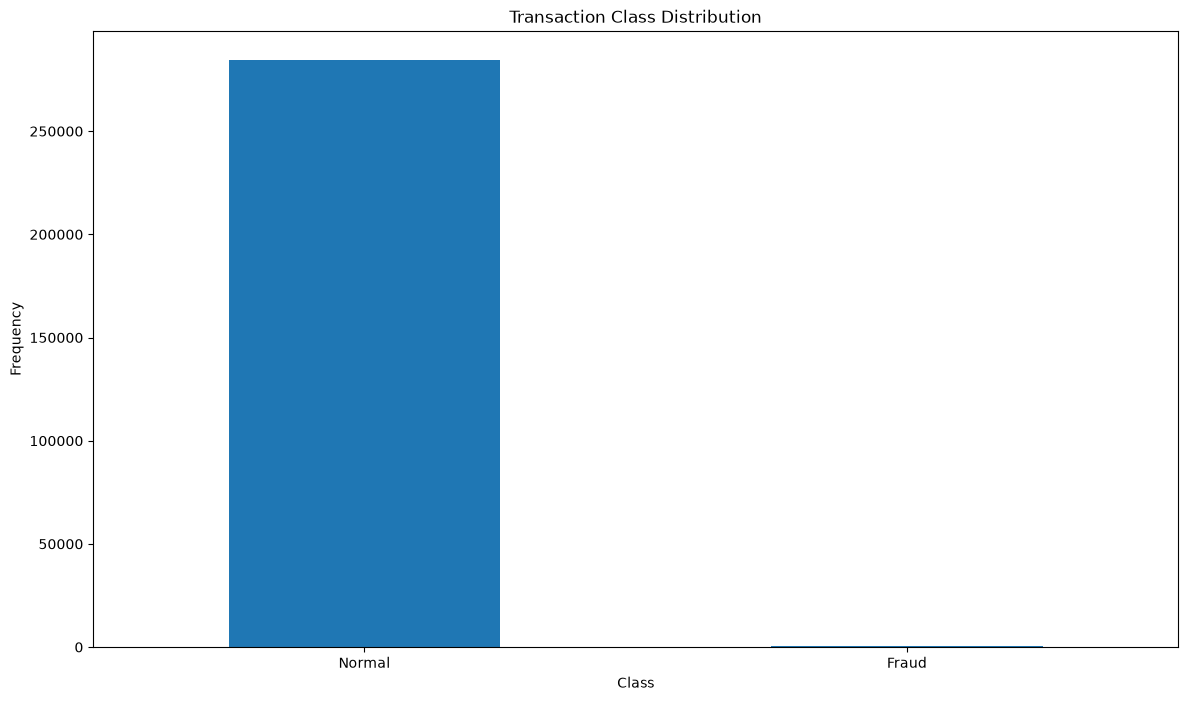

In [13]:
count_classes.plot(kind='bar', rot=0)

plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

plt.show()

In [14]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

print("Fraud transactions:", fraud.shape)
print("Normal transactions:", normal.shape)

Fraud transactions: (492, 31)
Normal transactions: (284315, 31)


In [15]:
print("Fraud amount statistics:")
print(fraud.Amount.describe())

print("\nNormal amount statistics:")
print(normal.Amount.describe())

Fraud amount statistics:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal amount statistics:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


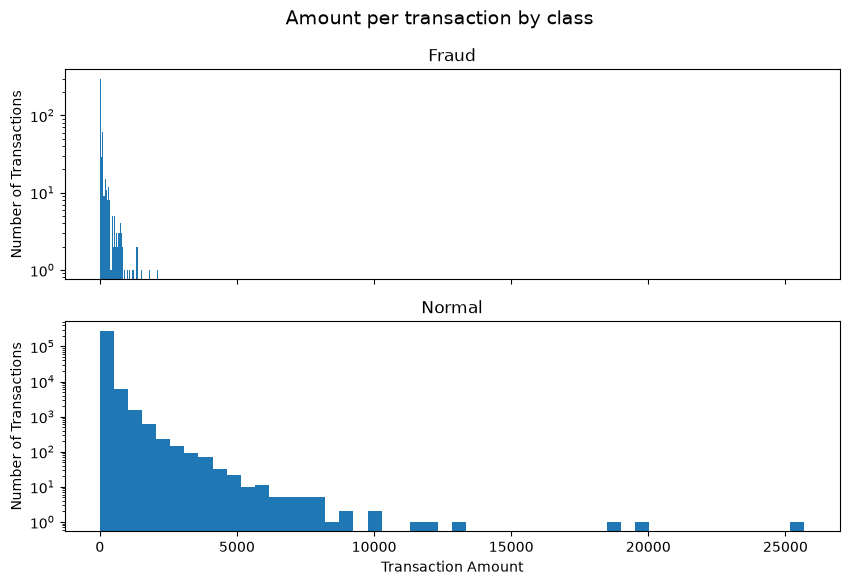

In [16]:
f, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True
)

f.suptitle(
    'Amount per transaction by class',
    fontsize=14
)

bins = 50

ax1.hist(fraud.Amount, bins=bins)
ax1.set_title('Fraud')
ax1.set_ylabel('Number of Transactions')
ax1.set_yscale('log')

ax2.hist(normal.Amount, bins=bins)
ax2.set_title('Normal')
ax2.set_ylabel('Number of Transactions')
ax2.set_xlabel('Transaction Amount')
ax2.set_yscale('log')

plt.show()

In [17]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

print("Fraud:", fraud.shape)
print("Normal:", normal.shape)

Fraud: (492, 31)
Normal: (284315, 31)


In [18]:
X = data.drop('Class', axis=1)
y = data['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [19]:
RANDOM_SEED = 42

outlier_fraction = len(fraud) / float(len(normal))

print("Outlier fraction:", outlier_fraction)

Outlier fraction: 0.0017304750013189597


In [20]:
isolation_forest = IsolationForest(
    n_estimators=100,
    max_samples=len(X),
    contamination=outlier_fraction,
    random_state=RANDOM_SEED
)

isolation_forest.fit(X)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


In [21]:
y_pred_if = isolation_forest.predict(X)

print("Predictions generated successfully")
print("Prediction values:", np.unique(y_pred_if))

Predictions generated successfully
Prediction values: [-1  1]


In [22]:
y_pred_if = np.where(y_pred_if == -1, 1, 0)

print("Converted predictions successfully")

Converted predictions successfully


In [23]:
print(classification_report(y, y_pred_if, target_names=LABELS))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.31      0.31      0.31       492

    accuracy                           1.00    284807
   macro avg       0.65      0.65      0.65    284807
weighted avg       1.00      1.00      1.00    284807



In [24]:
print("Accuracy:", accuracy_score(y, y_pred_if))

Accuracy: 0.9976159293837581


In [ ]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=outlier_fraction
)

y_pred_lof = lof.fit_predict(X)

print("LOF predictions generated successfully")
print("Prediction values:", np.unique(y_pred_lof))

In [ ]:
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

print("LOF predictions converted successfully")

In [ ]:
print(classification_report(
    y,
    y_pred_lof,
    target_names=LABELS
))

In [ ]:
print("LOF Accuracy:", accuracy_score(y, y_pred_lof))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred_lof)

print("Confusion Matrix:")
print(cm)